# Function 2 Analysis — Week 11

1. **Function description:** Imagine a black box, or a mystery ML model, that takes two numbers as input and returns a log-likelihood score. Your goal is to maximise that score, but each output is noisy, and depending on where you start, you might get stuck in a local optimum. To tackle this, you use Bayesian optimisation, which selects the next inputs based on what it has learned so far. It balances exploration with exploitation, making it well suited to noisy outputs and complex functions with many local peaks.

2. **Week 10 evaluated point:** `(0.697966, 0.991186)` returned **≈0.6416**, so it was **not better** than the incumbent best.

3. **Analysis of last point:** The local region remains strong, but this result reinforces that the boundary ridge is noisy and sensitive to tiny moves.

4. **Why we chose last week’s point (from Week 10 rationale):** Week 10 kept Thompson Sampling near the strongest boundary ridge because the surface remained noisy and multimodal, so local robustness was preferable to broad exploration.

5. **Recommendation for Week 12 (and why):** Keep the same local Thompson-sampling strategy and stay near the incumbent ridge with a controlled local move. Recommended candidate (from Thompson sample): **`(0.703898, 0.982373)`**.


In [13]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_2")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1–8 new points
X_new_point_week_1 = np.array([[0.850000, 0.250000]])
y_new_point_week_1 = np.array([0.4588155729748088])
X_new_point_week_2 = np.array([[0.535400, 0.505100]])
y_new_point_week_2 = np.array([0.4687657102198476])
X_new_point_week_3 = np.array([[0.700000, 0.525000]])
y_new_point_week_3 = np.array([0.5521137017632074])
X_new_point_week_4 = np.array([[0.272472, 0.939888]])
y_new_point_week_4 = np.array([-0.04847445058575585])
X_new_point_week_5 = np.array([[0.680788, 1.000000]])
y_new_point_week_5 = np.array([0.4711629392317611])
X_new_point_week_6 = np.array([[0.734569, 0.990000]])
y_new_point_week_6 = np.array([0.3100296239758809])
X_new_point_week_7 = np.array([[0.680788, 1.000000]])
y_new_point_week_7 = np.array([0.67032012103923])
X_new_point_week_8 = np.array([[0.690000, 0.900000]])
y_new_point_week_8 = np.array([0.6255292381456191])
X_new_point_week_9 = np.array([[0.692542, 0.990644]])
y_new_point_week_9 = np.array([0.745718066464249])
X_new_point_week_10 = np.array([[0.697966, 0.991186]])
y_new_point_week_10 = np.array([0.6416389773332486])

X = np.vstack([
    X,
    X_new_point_week_1,
    X_new_point_week_2,
    X_new_point_week_3,
    X_new_point_week_4,
    X_new_point_week_5,
    X_new_point_week_6,
    X_new_point_week_7,
    X_new_point_week_8,
    X_new_point_week_9,
    X_new_point_week_10,
])
y = np.concatenate([
    y,
    y_new_point_week_1,
    y_new_point_week_2,
    y_new_point_week_3,
    y_new_point_week_4,
    y_new_point_week_5,
    y_new_point_week_6,
    y_new_point_week_7,
    y_new_point_week_8,
    y_new_point_week_9,
    y_new_point_week_10,
])

df = pd.DataFrame(X, columns=["x1", "x2"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
display(df_sorted)


,x1,x2,y
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205


df sorted by y


,x1,x2,y
0,0.692542,0.990644,0.745718
1,0.680788,1.000000,0.670320
2,0.697966,0.991186,0.641639
3,0.690000,0.900000,0.625529
4,0.702637,0.926564,0.611205
5,0.700000,0.525000,0.552114
6,0.665800,0.123969,0.538996
7,0.680788,1.000000,0.471163
8,0.535400,0.505100,0.468766
9,0.850000,0.250000,0.458816


In [14]:
# Build weekly progress dataframe from available week variables (auto-detect)
weekly_X, weekly_y = [], []
week_idx = 1
while f'X_new_point_week_{week_idx}' in globals() and f'y_new_point_week_{week_idx}' in globals():
    weekly_X.append(globals()[f'X_new_point_week_{week_idx}'])
    weekly_y.append(globals()[f'y_new_point_week_{week_idx}'])
    week_idx += 1

df_weeks = pd.DataFrame({
    'Week': range(1, len(weekly_X) + 1),
    'x1': [x[0, 0] for x in weekly_X],
    'x2': [x[0, 1] for x in weekly_X],
    'y': [y[0] for y in weekly_y]
})

# Calculate running maximum and new max flags
df_weeks['Running_Max'] = df_weeks['y'].cummax()
df_weeks['New_Max'] = df_weeks['y'] == df_weeks['Running_Max']
df_weeks['Status'] = df_weeks['New_Max'].map({True: '✓ NEW MAX', False: '✗'})
df_weeks['Prev_Max'] = df_weeks['Running_Max'].shift(1).fillna(0)
df_weeks['Improvement'] = np.where(df_weeks['New_Max'], df_weeks['y'] - df_weeks['Prev_Max'], np.nan)

# Display table
print('=' * 90)
print('WEEKLY OPTIMIZATION PROGRESS')
print('=' * 90)
df_display = df_weeks[['Week', 'x1', 'x2', 'y', 'Running_Max', 'Status', 'Improvement']].copy()
df_display['Improvement'] = df_display['Improvement'].apply(lambda x: f'+{x:.6f}' if pd.notna(x) else '-')
display(df_display)

# Summary statistics
new_max_weeks = df_weeks[df_weeks['New_Max']]['Week'].tolist()
print(f"\n📊 Summary: {df_weeks['New_Max'].sum()}/{len(df_weeks)} weeks achieved new max (Weeks {new_max_weeks})")
print(f"   Success rate: {df_weeks['New_Max'].sum() / len(df_weeks) * 100:.1f}% | Final best: {df_weeks['y'].max():.6f} | Improvement: {df_weeks['y'].max() / df_weeks['y'].iloc[0]:.1f}x from Week 1")

WEEKLY OPTIMIZATION PROGRESS


,Week,x1,x2,y,Running_Max,Status,Improvement
0,1,0.850000,0.250000,0.458816,0.458816,✓ NEW MAX,+0.458816
1,2,0.535400,0.505100,0.468766,0.468766,✓ NEW MAX,+0.009950
2,3,0.700000,0.525000,0.552114,0.552114,✓ NEW MAX,+0.083348
3,4,0.272472,0.939888,-0.048474,0.552114,✗,-
4,5,0.680788,1.000000,0.471163,0.552114,✗,-
5,6,0.734569,0.990000,0.310030,0.552114,✗,-
6,7,0.680788,1.000000,0.670320,0.670320,✓ NEW MAX,+0.118206
7,8,0.690000,0.900000,0.625529,0.670320,✗,-
8,9,0.692542,0.990644,0.745718,0.745718,✓ NEW MAX,+0.075398
9,10,0.697966,0.991186,0.641639,0.745718,✗,-



📊 Summary: 5/10 weeks achieved new max (Weeks [1, 2, 3, 7, 9])
   Success rate: 50.0% | Final best: 0.745718 | Improvement: 1.6x from Week 1


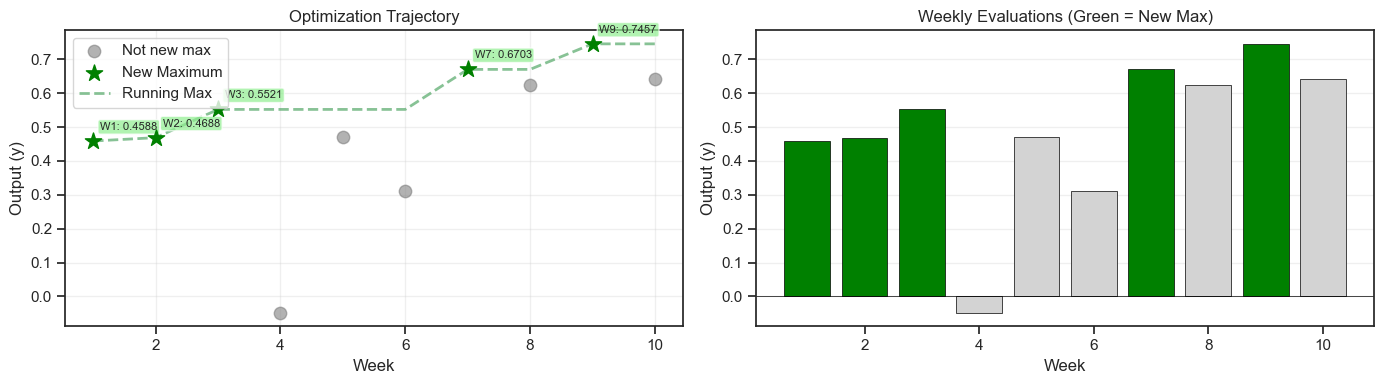

In [15]:
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

weeks = df_weeks['Week']
y_vals = df_weeks['y']
new_max_mask = df_weeks['New_Max']

# Left plot: Scatter with running max line
ax1.scatter(weeks[~new_max_mask], y_vals[~new_max_mask], color='gray', s=80, alpha=0.6, label='Not new max')
ax1.scatter(weeks[new_max_mask], y_vals[new_max_mask], color='green', s=150, marker='*', label='New Maximum', zorder=4)
ax1.plot(weeks, df_weeks['Running_Max'], 'g--', alpha=0.7, lw=2, label='Running Max')
for _, row in df_weeks[new_max_mask].iterrows():
    ax1.annotate(f"W{int(row['Week'])}: {row['y']:.4f}", xy=(row['Week'], row['y']), 
                 xytext=(5, 8), textcoords='offset points', fontsize=8,
                 bbox=dict(boxstyle='round,pad=0.2', fc='lightgreen', alpha=0.7))
ax1.set_xlabel('Week'); ax1.set_ylabel('Output (y)')
ax1.set_title('Optimization Trajectory'); ax1.legend(loc='upper left'); ax1.grid(True, alpha=0.3)

# Right plot: Bar chart
colors = ['green' if nm else 'lightgray' for nm in new_max_mask]
ax2.bar(weeks, y_vals, color=colors, edgecolor='black', lw=0.5)
ax2.axhline(y=0, color='black', lw=0.5)
ax2.set_xlabel('Week'); ax2.set_ylabel('Output (y)')
ax2.set_title('Weekly Evaluations (Green = New Max)'); ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

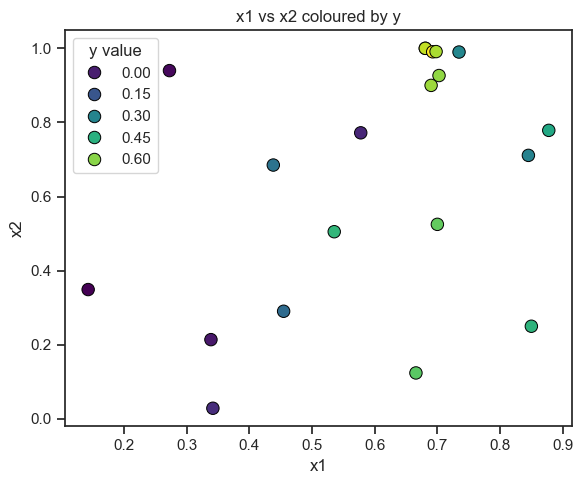

In [16]:
plt.figure(figsize=(6, 5))
scatter = sns.scatterplot(data=df, x="x1", y="x2", hue="y", palette="viridis", s=80, edgecolor="black")

# Overlay the updated manual recommendation (if computed above)
try:
    plt.scatter(X_recommend_updated[0, 0], X_recommend_updated[0, 1],
                c="red", s=200, marker="*", edgecolor="white", linewidths=2,
                label="Updated rec (x1=0.7 midpoint)")
except NameError:
    pass

plt.title("x1 vs x2 coloured by y")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend(title="y value")
plt.tight_layout()
plt.show()


In [17]:
# Thompson Sampling (noisy optimization)
# ======================================
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel

# Prepare training data
X_train = df[["x1", "x2"]].values
y_train = df["y"].values
best_idx = df["y"].idxmax()
best_point = df.loc[best_idx]

print(f"Current best: ({best_point.x1:.4f}, {best_point.x2:.4f}) = {best_point.y:.4f}")
print(f"Note: Same point (0.6808, 1.0) gave 0.471 and 0.670 on different evals — high noise!\n")

# GP with HIGH noise term: initial values and bounds only; actual length_scale and noise_level are fitted (optimized)
kernel_ts = (
    ConstantKernel(1.0, (1e-3, 50.0))
    * Matern(length_scale=[0.15, 0.15], length_scale_bounds=(0.05, 0.5), nu=2.5)
    + WhiteKernel(noise_level=0.15, noise_level_bounds=(0.05, 0.5))  # High noise; value optimized within bounds
)
gp_ts = GaussianProcessRegressor(kernel=kernel_ts, normalize_y=True, n_restarts_optimizer=15, random_state=42)
gp_ts.fit(X_train, y_train)

print(f"Fitted GP kernel: {gp_ts.kernel_}")
print("Interpretation: The values above are the *result of optimization* (maximizing the")
print("log-marginal-likelihood). The code only sets *initial* values and *bounds* (e.g. length_scale")
print("bounds (0.05, 0.5), noise_level bounds (0.05, 0.5)); the fitted length scales and")
print("noise_level are optimized within those bounds. ConvergenceWarnings mean the optimizer")
print("hit a bound (e.g. length_scale[0]=0.05, length_scale[1]=0.5) — you could widen bounds if needed.\n")

# Search region: strip near the boundary where we've seen best results
ts_x1_min, ts_x1_max = 0.67, 0.72
ts_x2_min, ts_x2_max = 0.98, 1.00  # Tight to the boundary

grid_res = 60
ts_grid_x1 = np.linspace(ts_x1_min, ts_x1_max, grid_res)
ts_grid_x2 = np.linspace(ts_x2_min, ts_x2_max, grid_res)
ts_mesh = np.array(np.meshgrid(ts_grid_x1, ts_grid_x2)).reshape(2, -1).T

# Min improvement: only consider points at least 0.1 away from current best (avoids recommending too-close points with high noise)
dist_to_best = np.sqrt((ts_mesh[:, 0] - best_point.x1) ** 2 + (ts_mesh[:, 1] - best_point.x2) ** 2)
min_step = 0.1

# Thompson Sampling: draw multiple posterior samples and pick the best point from each (among points >= min_step from best)
n_ts_samples = 10
ts_recommendations = []

np.random.seed(42)
for i in range(n_ts_samples):
    # Draw a sample from the posterior at all candidate points
    y_sample = gp_ts.sample_y(ts_mesh, n_samples=1, random_state=np.random.randint(0, 10000)).flatten()
    # Exclude points too close to current best (min improvement term)
    y_sample = y_sample.copy()
    y_sample[dist_to_best < min_step] = -np.inf
    
    # Find the point where this sample is highest (among feasible points)
    best_sample_idx = np.argmax(y_sample)
    best_sample_point = ts_mesh[best_sample_idx]
    best_sample_value = y_sample[best_sample_idx]
    # Only add if we had at least one point >= min_step away (else skip this sample)
    if best_sample_value > -np.inf:
        ts_recommendations.append({
            'x1': best_sample_point[0],
            'x2': best_sample_point[1],
            'sampled_y': best_sample_value
        })

# If no point was >= min_step away (e.g. search region too tight), add one recommendation without the constraint
if not ts_recommendations:
    y_sample = gp_ts.sample_y(ts_mesh, n_samples=1, random_state=0).flatten()
    best_sample_idx = np.argmax(y_sample)
    best_sample_point = ts_mesh[best_sample_idx]
    ts_recommendations.append({'x1': best_sample_point[0], 'x2': best_sample_point[1], 'sampled_y': y_sample[best_sample_idx]})
    print("Note: no point was >= 0.1 from best; using one unconstrained sample.")

ts_df = pd.DataFrame(ts_recommendations)
print("Thompson Sampling: Best points from posterior samples (min step 0.1 from best)")
display(ts_df)

# Aggregate: which point appears most often or has highest average?
# Use the mode (most frequently recommended region)
ts_df['x1_round'] = ts_df['x1'].round(3)
ts_df['x2_round'] = ts_df['x2'].round(3)
mode_point = ts_df.groupby(['x1_round', 'x2_round']).size().idxmax()
print(f"\nMost frequently recommended region: x1≈{mode_point[0]:.3f}, x2≈{mode_point[1]:.3f}")

# Final recommendation: average of the TS recommendations (robust)
final_x1 = ts_df['x1'].mean()
final_x2 = ts_df['x2'].mean()
print(f"Average TS recommendation: ({final_x1:.6f}, {final_x2:.6f})")

Current best: (0.6925, 0.9906) = 0.7457
Note: Same point (0.6808, 1.0) gave 0.471 and 0.670 on different evals — high noise!

Fitted GP kernel: 0.918**2 * Matern(length_scale=[0.05, 0.5], nu=2.5) + WhiteKernel(noise_level=0.112)
Interpretation: The values above are the *result of optimization* (maximizing the
log-marginal-likelihood). The code only sets *initial* values and *bounds* (e.g. length_scale
bounds (0.05, 0.5), noise_level bounds (0.05, 0.5)); the fitted length scales and
noise_level are optimized within those bounds. ConvergenceWarnings mean the optimizer
hit a bound (e.g. length_scale[0]=0.05, length_scale[1]=0.5) — you could widen bounds if needed.



d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 0.5. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Note: no point was >= 0.1 from best; using one unconstrained sample.
Thompson Sampling: Best points from posterior samples (min step 0.1 from best)


,x1,x2,sampled_y
0,0.703898,0.982373,0.95647



Most frequently recommended region: x1≈0.704, x2≈0.982
Average TS recommendation: (0.703898, 0.982373)


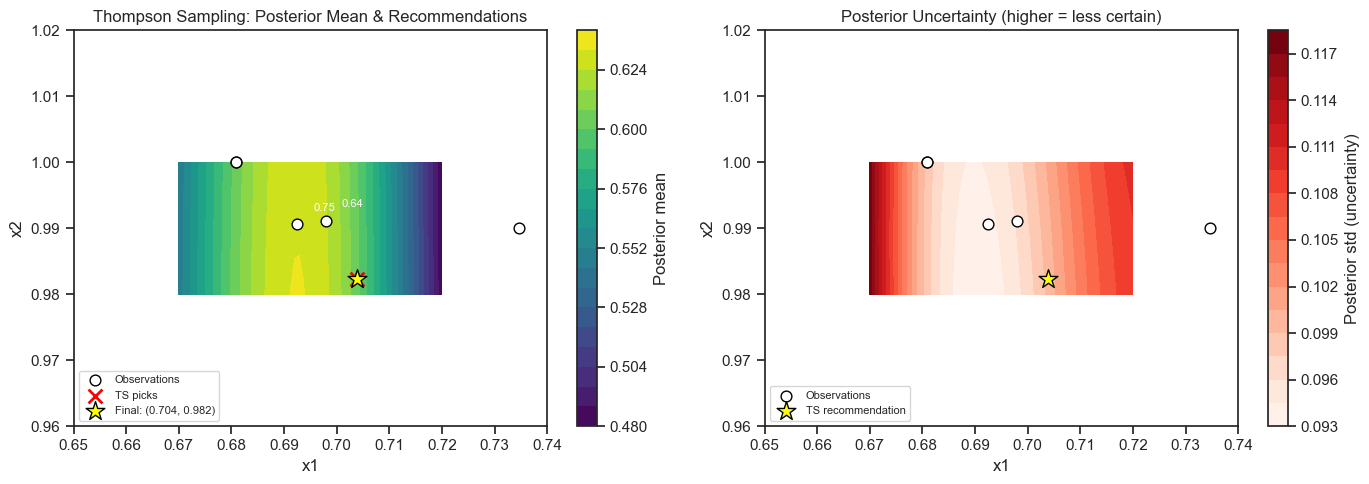


THOMPSON SAMPLING RECOMMENDED POINT: (0.703898, 0.982373)
Format for submission: 0.703898-0.982373


In [18]:
# Visualize Thompson Sampling results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: GP posterior mean with TS recommendations
mu_ts, sigma_ts = gp_ts.predict(ts_mesh, return_std=True)
mu_grid = mu_ts.reshape(grid_res, grid_res)

contour = ax1.contourf(ts_grid_x1, ts_grid_x2, mu_grid, levels=20, cmap='viridis')
plt.colorbar(contour, ax=ax1, label='Posterior mean')

# Observed points
ax1.scatter(df['x1'], df['x2'], c='white', s=60, edgecolor='black', zorder=5, label='Observations')
for _, row in df.iterrows():
    if ts_x1_min <= row['x1'] <= ts_x1_max and ts_x2_min - 0.05 <= row['x2'] <= ts_x2_max + 0.05:
        ax1.annotate(f"{row['y']:.2f}", (row['x1']+0.003, row['x2']+0.002), fontsize=8, color='white')

# TS recommendations (scatter)
ax1.scatter(ts_df['x1'], ts_df['x2'], c='red', s=100, marker='x', linewidths=2, zorder=6, label='TS picks')

# Final recommendation
ax1.scatter(final_x1, final_x2, c='yellow', s=200, marker='*', edgecolor='black', zorder=7, 
            label=f'Final: ({final_x1:.3f}, {final_x2:.3f})')

ax1.set_xlim(ts_x1_min - 0.02, ts_x1_max + 0.02)
ax1.set_ylim(ts_x2_min - 0.02, ts_x2_max + 0.02)
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_title('Thompson Sampling: Posterior Mean & Recommendations')
ax1.legend(loc='lower left', fontsize=8)

# Right: Posterior uncertainty (shows where noise is high)
sigma_grid = sigma_ts.reshape(grid_res, grid_res)
contour2 = ax2.contourf(ts_grid_x1, ts_grid_x2, sigma_grid, levels=20, cmap='Reds')
plt.colorbar(contour2, ax=ax2, label='Posterior std (uncertainty)')

ax2.scatter(df['x1'], df['x2'], c='white', s=60, edgecolor='black', zorder=5, label='Observations')
ax2.scatter(final_x1, final_x2, c='yellow', s=200, marker='*', edgecolor='black', zorder=7, label='TS recommendation')

ax2.set_xlim(ts_x1_min - 0.02, ts_x1_max + 0.02)
ax2.set_ylim(ts_x2_min - 0.02, ts_x2_max + 0.02)
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.set_title('Posterior Uncertainty (higher = less certain)')
ax2.legend(loc='lower left', fontsize=8)

plt.tight_layout()
plt.show()

# Print final recommendation
print(f"\n{'='*60}")
print(f"THOMPSON SAMPLING RECOMMENDED POINT: ({final_x1:.6f}, {final_x2:.6f})")
print(f"Format for submission: {final_x1:.6f}-{final_x2:.6f}")
print(f"{'='*60}")

**Current best:** `0.692542-0.990644` (≈0.7457)

**Week 10 evaluated point:** `0.697966-0.991186` → ≈0.6416 (not a new maximum).

**Proposed next point (submission format):** `0.703898-0.982373`

Using the Thompson-sampling recommendation, we keep a local move near the incumbent ridge while still allowing controlled stochastic exploration.
